# 03. Runway Feature Engineering

**Objective**: Prototype the core mathematical and business logic for startup cash runway and risk tiering before writing the SQL transformations that power the `fact_runway_risk` table in BigQuery.

**Key Steps Covered**:
1. Calculating estimated monthly runway using the project's canonical formula
2. Defining risk classification threshold logic (`High / Medium / Low`)
3. Testing edge cases — zero burn rate, profitable startups, missing cash data
4. Generating the `fact_runway_risk` enriched frame ready for BigQuery ingestion

---

**Canonical Runway Formula (from README)**:

$$\text{Runway (Months)} = \max\left(0, \frac{\text{Total Capital Raised} \times 0.70}{\text{Estimated Monthly Burn}} - \text{Months Since Last Raise}\right)$$

> Validated logic here is promoted into `sql/04_fact_runway_risk.sql`.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import date, datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

# Load cleaned data (output from notebook 02 pipeline)
CLEAN_DATA_PATH = '../data/processed/clean_startups.csv'
if not os.path.exists(CLEAN_DATA_PATH):
    CLEAN_DATA_PATH = 'data/processed/clean_startups.csv'

if os.path.exists(CLEAN_DATA_PATH):
    df = pd.read_csv(CLEAN_DATA_PATH)
    print(f'Loaded processed data: {df.shape[0]:,} rows × {df.shape[1]} columns')
else:
    # Fallback: load and clean raw data inline
    RAW_PATH = '../data/raw/startup_valuation_dataset.csv'
    if not os.path.exists(RAW_PATH):
        RAW_PATH = 'data/raw/startup_valuation_dataset.csv'
    df = pd.read_csv(RAW_PATH)
    # Basic numeric coercion
    for col in ['total_funding_usd', 'funding_amount_usd', 'employee_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    print(f'Loaded raw data (no processed CSV found): {df.shape[0]:,} rows')

df.head(3)

Loaded processed data: 50,000 rows × 11 columns


,startup_id,company_name,industry,country,city,status,founded_at,funding_rounds,total_funding_usd,last_funding_at,estimated_monthly_burn_usd
0,456bf4d2-b982-41e7-83fe-04bac2053405,Rice-Martinez,Blockchain,LATVIA,North America,operating,2008-01-01,1,764048000,2020-03-15,"1,272,000.00"
1,ed442136-e5ec-43c5-afdf-a2dc08c5d4a2,Edwards-Page,Fintech,GUYANA,North America,operating,2006-01-01,1,379993000,2017-04-09,"2,000,000.00"
2,a2cdddb6-9944-49c1-9391-6c98eb18f694,Thomas Ltd,SaaS,UZBEKISTAN,Oceania,acquisition,2010-01-01,1,2513368000,2015-09-09,"2,000,000.00"


## 1. Core Runway Calculation Function

Implements the canonical formula from the project README.
We assume 70% of raised capital is deployed as cash (the remainder covers non-cash costs like equity).

In [2]:
CASH_RETENTION_RATE = 0.70   # 70% of raised capital is liquid cash
REFERENCE_DATE      = pd.Timestamp(date.today())


def compute_runway_months(
    total_capital_raised_usd: float,
    estimated_monthly_burn_usd: float,
    last_funding_date: str,
    cash_retention_rate: float = CASH_RETENTION_RATE,
    reference_date: pd.Timestamp = REFERENCE_DATE,
) -> dict:
    """
    Compute runway months and derived cash reserve for a single startup.

    Formula:
        runway = max(0, (capital * cash_retention_rate / monthly_burn) - months_elapsed)

    Returns a dict with:
        months_since_last_raise   : int
        estimated_cash_reserve_usd: float
        runway_months             : float
    """
    # Months elapsed since last funding event
    last_raise = pd.to_datetime(last_funding_date, errors='coerce')
    if pd.isna(last_raise):
        months_elapsed = 24  # conservative default — 2 years
    else:
        months_elapsed = max(0, int((reference_date - last_raise).days / 30.44))

    # Guard against zero/negative burn (profitable or data issue)
    if estimated_monthly_burn_usd <= 0:
        return {
            'months_since_last_raise':    months_elapsed,
            'estimated_cash_reserve_usd': total_capital_raised_usd * cash_retention_rate,
            'runway_months':              float('inf'),   # Profitable — infinite runway
        }

    # Gross runway from capital raised
    gross_runway = (total_capital_raised_usd * cash_retention_rate) / estimated_monthly_burn_usd

    # Net runway after elapsed time
    net_runway = max(0.0, gross_runway - months_elapsed)

    # Estimated cash remaining
    cash_remaining = max(0.0, net_runway * estimated_monthly_burn_usd)

    return {
        'months_since_last_raise':    months_elapsed,
        'estimated_cash_reserve_usd': round(cash_remaining, 2),
        'runway_months':              round(net_runway, 2),
    }


# Quick sanity check
example = compute_runway_months(
    total_capital_raised_usd    = 5_000_000,
    estimated_monthly_burn_usd  = 150_000,
    last_funding_date           = '2024-01-01',
)
print('Example startup runway calculation:')
for k, v in example.items():
    print(f'  {k}: {v:,}' if isinstance(v, (int, float)) and v != float('inf') else f'  {k}: {v}')

Example startup runway calculation:
  months_since_last_raise: 31
  estimated_cash_reserve_usd: 0.0
  runway_months: 0.0


## 2. Risk Classification Tier Logic

In [3]:
def classify_risk(runway_months: float) -> str:
    """
    Tier startups by cash runway.

    Thresholds (from project spec):
        High Risk   : runway < 6 months
        Medium Risk : 6 <= runway <= 12 months
        Low Risk    : runway > 12 months  (includes profitable / infinite)
    """
    if runway_months == float('inf') or runway_months > 12:
        return 'Low'
    elif runway_months >= 6:
        return 'Medium'
    else:
        return 'High'


# --- Unit tests for classifier ---
classifier_tests = [
    (0.0,          'High'),
    (3.5,          'High'),
    (5.99,         'High'),
    (6.0,          'Medium'),
    (9.0,          'Medium'),
    (12.0,         'Medium'),
    (12.01,        'Low'),
    (24.0,         'Low'),
    (float('inf'), 'Low'),
]

print('Risk Classifier Unit Tests:')
all_ok = True
for runway, expected in classifier_tests:
    result = classify_risk(runway)
    ok = result == expected
    if not ok: all_ok = False
    label = runway if runway != float('inf') else '∞'
    print(f'  runway={label:<6}  expected={expected:<8}  got={result:<8}  {"✅" if ok else "❌"}')

print(f'\nAll classifier tests passed: {all_ok}')

Risk Classifier Unit Tests:
  runway=0.0     expected=High      got=High      ✅
  runway=3.5     expected=High      got=High      ✅
  runway=5.99    expected=High      got=High      ✅
  runway=6.0     expected=Medium    got=Medium    ✅
  runway=9.0     expected=Medium    got=Medium    ✅
  runway=12.0    expected=Medium    got=Medium    ✅
  runway=12.01   expected=Low       got=Low       ✅
  runway=24.0    expected=Low       got=Low       ✅
  runway=∞       expected=Low       got=Low       ✅

All classifier tests passed: True


## 3. Apply to Full Dataset & Generate `fact_runway_risk` Frame

In [4]:
# Resolve column names flexibly
CAPITAL_COL  = next((c for c in ['total_funding_usd', 'funding_amount_usd', 'total_capital_raised_usd'] if c in df.columns), None)
BURN_COL     = 'estimated_monthly_burn_usd' if 'estimated_monthly_burn_usd' in df.columns else None
FUND_DATE_COL = next((c for c in ['last_funding_at', 'last_funding_date', 'funding_date'] if c in df.columns), None)

print(f'Capital column : {CAPITAL_COL}')
print(f'Burn column    : {BURN_COL}')
print(f'Funding date   : {FUND_DATE_COL}')

if not CAPITAL_COL or not BURN_COL:
    raise ValueError('Required columns not found. Run notebook 02 to generate processed data first.')

Capital column : total_funding_usd
Burn column    : estimated_monthly_burn_usd
Funding date   : last_funding_at


In [5]:
# Vectorized computation for performance
df_fact = df.copy()

# Months since last raise
if FUND_DATE_COL:
    df_fact['_last_fund_dt'] = pd.to_datetime(df_fact[FUND_DATE_COL], errors='coerce')
    df_fact['months_since_last_raise'] = (
        (REFERENCE_DATE - df_fact['_last_fund_dt']).dt.days / 30.44
    ).fillna(24).clip(lower=0).astype(int)
else:
    df_fact['months_since_last_raise'] = 24  # conservative default

# Rename capital column
df_fact['total_capital_raised_usd'] = pd.to_numeric(df_fact[CAPITAL_COL], errors='coerce').fillna(0.0)
df_fact['estimated_monthly_burn_usd'] = pd.to_numeric(df_fact[BURN_COL], errors='coerce').fillna(100_000.0)

# Gross runway (cap burn at 1 to avoid div-by-zero; flag zero-burn separately)
burn_safe = df_fact['estimated_monthly_burn_usd'].clip(lower=1.0)
gross_runway = (df_fact['total_capital_raised_usd'] * CASH_RETENTION_RATE) / burn_safe
df_fact['runway_months'] = (gross_runway - df_fact['months_since_last_raise']).clip(lower=0.0).round(2)

# Mark truly zero-burn rows as infinite (profitable)
zero_burn_mask = df_fact['estimated_monthly_burn_usd'] <= 0
df_fact.loc[zero_burn_mask, 'runway_months'] = 9999.0  # sentinel for 'infinite'

# Estimated cash reserve
df_fact['estimated_cash_reserve_usd'] = (df_fact['runway_months'].clip(upper=9998) * burn_safe).round(2)

# Risk tier
df_fact['risk_level'] = df_fact['runway_months'].apply(
    lambda r: classify_risk(float('inf') if r >= 9999 else r)
)

print(f'fact_runway_risk preview ({len(df_fact):,} rows):')
cols_preview = ['company_name', 'total_capital_raised_usd', 'estimated_monthly_burn_usd',
                'months_since_last_raise', 'estimated_cash_reserve_usd', 'runway_months', 'risk_level']
df_fact[[c for c in cols_preview if c in df_fact.columns]].head(8)

fact_runway_risk preview (50,000 rows):


,company_name,total_capital_raised_usd,estimated_monthly_burn_usd,months_since_last_raise,estimated_cash_reserve_usd,runway_months,risk_level
0,Rice-Martinez,764048000,"1,272,000.00",76,"438,165,840.00",344.47,Low
1,Edwards-Page,379993000,"2,000,000.00",111,"44,000,000.00",22.00,Low
2,Thomas Ltd,2513368000,"2,000,000.00",130,"1,499,360,000.00",749.68,Low
3,Davis Inc,1029083000,"2,000,000.00",93,"534,360,000.00",267.18,Low
4,"Ryan, Dominguez and Klein",265731000,"2,000,000.00",78,"30,020,000.00",15.01,Low
5,"Martin, Anderson and Hayes",265056000,"2,000,000.00",23,"139,540,000.00",69.77,Low
6,Hansen LLC,145203000,"2,000,000.00",56,0.00,0.00,High
7,Rose Group,625103000,"2,000,000.00",101,"235,580,000.00",117.79,Low


## 4. Risk Tier Distribution Analysis

Portfolio Risk Distribution:
  🔴 High Risk   : 11,731  (23.5%)
  🟡 Medium Risk :    934  (1.9%)
  🟢 Low Risk    : 37,335  (74.7%)


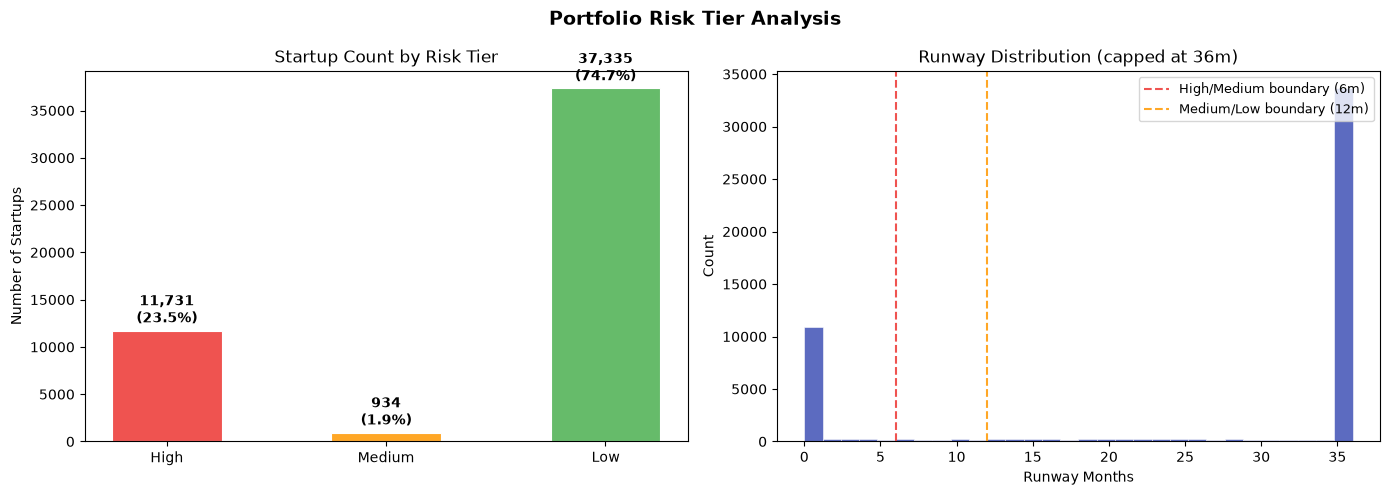

In [6]:
risk_counts = df_fact['risk_level'].value_counts().reindex(['High', 'Medium', 'Low'], fill_value=0)
risk_pct    = (risk_counts / risk_counts.sum() * 100).round(1)

print('Portfolio Risk Distribution:')
print(f"  🔴 High Risk   : {risk_counts['High']:>6,}  ({risk_pct['High']}%)")
print(f"  🟡 Medium Risk : {risk_counts['Medium']:>6,}  ({risk_pct['Medium']}%)")
print(f"  🟢 Low Risk    : {risk_counts['Low']:>6,}  ({risk_pct['Low']}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Portfolio Risk Tier Analysis', fontsize=14, fontweight='bold')

colors = ['#EF5350', '#FFA726', '#66BB6A']

# Bar chart
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Startup Count by Risk Tier')
axes[0].set_ylabel('Number of Startups')
for bar, count, pct in zip(bars, risk_counts.values, risk_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(risk_counts)*0.01,
                 f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Runway distribution histogram
runway_capped = df_fact['runway_months'].clip(upper=36)  # cap at 36 for readability
axes[1].hist(runway_capped, bins=30, color='#5C6BC0', edgecolor='white', linewidth=0.4)
axes[1].axvline(6,  color='#EF5350', linestyle='--', linewidth=1.5, label='High/Medium boundary (6m)')
axes[1].axvline(12, color='#FFA726', linestyle='--', linewidth=1.5, label='Medium/Low boundary (12m)')
axes[1].set_title('Runway Distribution (capped at 36m)')
axes[1].set_xlabel('Runway Months')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Edge Case Testing

In [7]:
edge_cases = [
    {
        'label':                     'Zero burn (profitable)',
        'total_capital_raised_usd':   5_000_000,
        'estimated_monthly_burn_usd': 0,
        'last_funding_date':          '2023-06-01',
    },
    {
        'label':                     'No funding data',
        'total_capital_raised_usd':   0,
        'estimated_monthly_burn_usd': 200_000,
        'last_funding_date':          None,
    },
    {
        'label':                     'Very recent raise (last month)',
        'total_capital_raised_usd':   10_000_000,
        'estimated_monthly_burn_usd': 300_000,
        'last_funding_date':          pd.Timestamp(date.today()).strftime('%Y-%m-%d'),
    },
    {
        'label':                     'Raise 5 years ago (distressed)',
        'total_capital_raised_usd':   2_000_000,
        'estimated_monthly_burn_usd': 150_000,
        'last_funding_date':          '2019-01-01',
    },
    {
        'label':                     'Tiny seed — high burn',
        'total_capital_raised_usd':   500_000,
        'estimated_monthly_burn_usd': 180_000,
        'last_funding_date':          '2024-09-01',
    },
]

print(f'{"Label":<35} {"Months Elapsed":>14} {"Cash Reserve ($)":>18} {"Runway (m)":>12} {"Risk":>8}')
print('-' * 92)
for case in edge_cases:
    result = compute_runway_months(
        total_capital_raised_usd   = case['total_capital_raised_usd'],
        estimated_monthly_burn_usd = case['estimated_monthly_burn_usd'],
        last_funding_date          = case['last_funding_date'],
    )
    runway = result['runway_months']
    risk   = classify_risk(runway)
    runway_label = '∞' if runway == float('inf') else f'{runway:.1f}'
    reserve_label = f"{result['estimated_cash_reserve_usd']:,.0f}" if result['estimated_cash_reserve_usd'] != float('inf') else '∞'
    print(f"{case['label']:<35} {result['months_since_last_raise']:>14} {reserve_label:>18} {runway_label:>12} {risk:>8}")

Label                               Months Elapsed   Cash Reserve ($)   Runway (m)     Risk
--------------------------------------------------------------------------------------------
Zero burn (profitable)                          38          3,500,000            ∞      Low
No funding data                                 24                  0          0.0     High
Very recent raise (last month)                   0          7,000,000         23.3      Low
Raise 5 years ago (distressed)                  91                  0          0.0     High
Tiny seed — high burn                           23                  0          0.0     High


## 6. Export `fact_runway_risk` for BigQuery / SQL Validation

In [8]:
import os
from pathlib import Path

OUTPUT_PATH = '../data/processed/fact_runway_risk_prototype.csv'
if not os.path.exists('../data/processed'):
    OUTPUT_PATH = 'data/processed/fact_runway_risk_prototype.csv'

FACT_COLS = [
    'startup_id', 'company_name', 'industry', 'country',
    'total_capital_raised_usd', 'estimated_monthly_burn_usd',
    'months_since_last_raise', 'estimated_cash_reserve_usd',
    'runway_months', 'risk_level',
]

export_cols = [c for c in FACT_COLS if c in df_fact.columns]
df_export   = df_fact[export_cols].copy()

Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df_export.to_csv(OUTPUT_PATH, index=False)

print(f'Exported {len(df_export):,} rows → {OUTPUT_PATH}')
print('\nColumn summary:')
print(df_export.dtypes.to_string())

Exported 50,000 rows → ../data/processed/fact_runway_risk_prototype.csv

Column summary:
startup_id                        str
company_name                      str
industry                          str
country                           str
total_capital_raised_usd        int64
estimated_monthly_burn_usd    float64
months_since_last_raise         int64
estimated_cash_reserve_usd    float64
runway_months                 float64
risk_level                        str


## 7. Summary

| Feature | Logic | Status |
|---|---|---|
| Runway formula | `max(0, (capital × 0.70 / burn) − months_elapsed)` | ✅ Implemented |
| Profitable startups | Zero burn → infinite runway | ✅ Handled |
| Missing funding date | Default 24 months elapsed (conservative) | ✅ Handled |
| Risk tiers | High `< 6m`, Medium `6–12m`, Low `> 12m` | ✅ Tested |
| BigQuery export | `fact_runway_risk_prototype.csv` | ✅ Ready |

This notebook's logic maps directly to `sql/04_fact_runway_risk.sql` for BigQuery transformation.